In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
from google.colab import files

uploaded = files.upload()

Saving medical_dataset_1500_records_10_diseases.csv to medical_dataset_1500_records_10_diseases.csv


In [3]:
data = pd.read_csv(
    "medical_dataset_1500_records_10_diseases.csv"
)

data.head()

,Age,Fever,Cough,Fatigue,Headache,Nausea,Dizziness,Chest_Pain,Shortness_of_Breath,Sore_Throat,Body_Pain,BP,Sugar,Oxygen_Level,Disease
0,69,0,0,0,0,0,1,1,1,0,0,160,80,99,Heart Disease
1,75,0,0,0,0,0,1,1,1,0,0,150,92,97,Heart Disease
2,70,1,1,1,0,0,0,0,1,0,0,113,77,90,Pneumonia
3,19,0,0,0,1,1,1,0,0,0,0,121,99,96,Migraine
4,50,0,0,0,1,1,1,0,0,0,0,121,95,99,Migraine


In [4]:
print("Dataset Shape:")
print(data.shape)

print("\nColumns:")
print(data.columns)

print("\nMissing Values:")
print(data.isnull().sum())


Dataset Shape:
(1500, 15)

Columns:
Index(['Age', 'Fever', 'Cough', 'Fatigue', 'Headache', 'Nausea', 'Dizziness',
       'Chest_Pain', 'Shortness_of_Breath', 'Sore_Throat', 'Body_Pain', 'BP',
       'Sugar', 'Oxygen_Level', 'Disease'],
      dtype='object')

Missing Values:
Age                    0
Fever                  0
Cough                  0
Fatigue                0
Headache               0
Nausea                 0
Dizziness              0
Chest_Pain             0
Shortness_of_Breath    0
Sore_Throat            0
Body_Pain              0
BP                     0
Sugar                  0
Oxygen_Level           0
Disease                0
dtype: int64


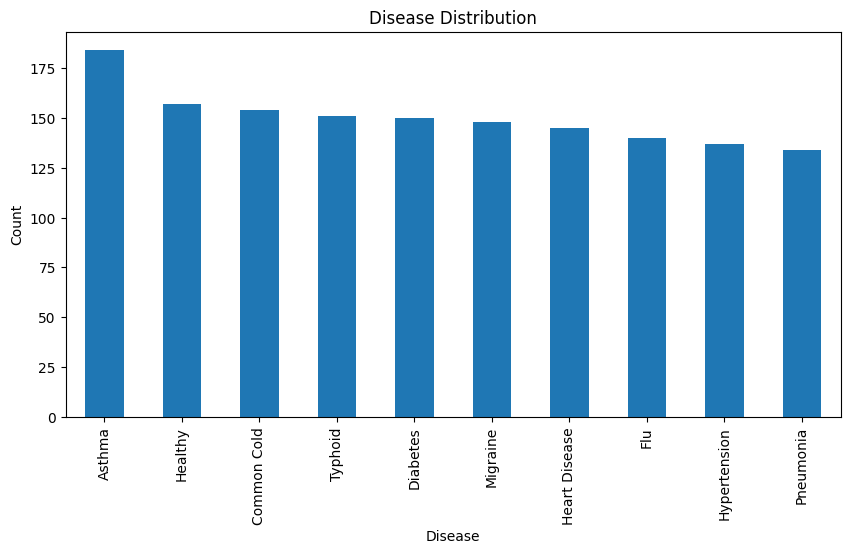

In [5]:
plt.figure(figsize=(10,5))

data['Disease'].value_counts().plot(
    kind='bar'
)

plt.title("Disease Distribution")
plt.xlabel("Disease")
plt.ylabel("Count")

plt.show()

In [6]:
encoder = LabelEncoder()

data['Disease'] = encoder.fit_transform(
    data['Disease']
)

print(
    dict(
        zip(
            encoder.classes_,
            encoder.transform(
                encoder.classes_
            )
        )
    )
)

{'Asthma': np.int64(0), 'Common Cold': np.int64(1), 'Diabetes': np.int64(2), 'Flu': np.int64(3), 'Healthy': np.int64(4), 'Heart Disease': np.int64(5), 'Hypertension': np.int64(6), 'Migraine': np.int64(7), 'Pneumonia': np.int64(8), 'Typhoid': np.int64(9)}


In [7]:
X = data.drop(
    'Disease',
    axis=1
)

y = data['Disease']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1200, 14)
Testing Data: (300, 14)


In [9]:
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

print("Model Trained Successfully")

Model Trained Successfully


In [10]:
y_pred = model.predict(
    X_test
)

In [11]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    round(
        accuracy*100,
        2
    ),
    "%"
)

Accuracy: 100.0 %


In [12]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        44
           1       1.00      1.00      1.00        30
           2       1.00      1.00      1.00        26
           3       1.00      1.00      1.00        27
           4       1.00      1.00      1.00        28
           5       1.00      1.00      1.00        31
           6       1.00      1.00      1.00        31
           7       1.00      1.00      1.00        32
           8       1.00      1.00      1.00        21
           9       1.00      1.00      1.00        30

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



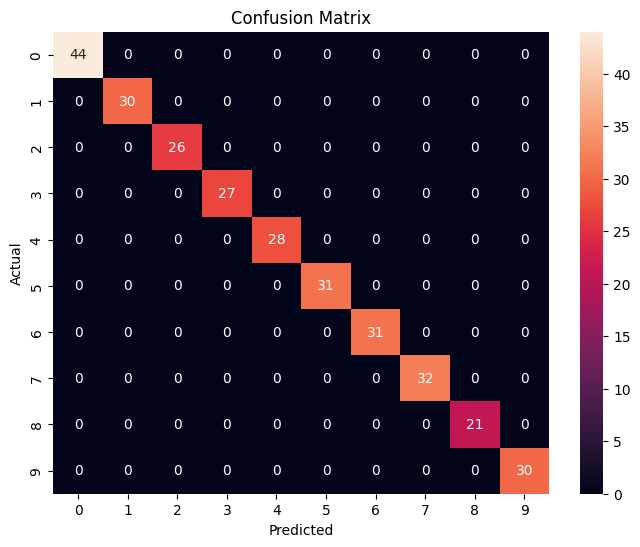

In [13]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(
    figsize=(8,6)
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

In [14]:
importance = pd.DataFrame(
    {
        'Feature':X.columns,
        'Importance':
        model.feature_importances_
    }
)

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                Feature  Importance
3               Fatigue    0.128710
1                 Fever    0.094466
2                 Cough    0.083882
5                Nausea    0.080453
10            Body_Pain    0.076882
4              Headache    0.073405
8   Shortness_of_Breath    0.072992
13         Oxygen_Level    0.072769
9           Sore_Throat    0.071864
12                Sugar    0.071550
11                   BP    0.067571
6             Dizziness    0.059029
7            Chest_Pain    0.040893
0                   Age    0.005535


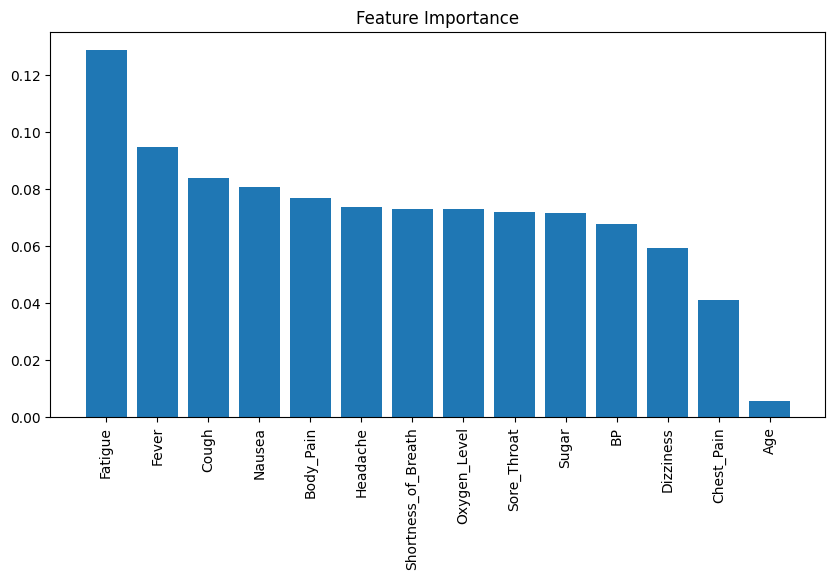

In [15]:
plt.figure(
    figsize=(10,5)
)

plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.xticks(
    rotation=90
)

plt.title(
    "Feature Importance"
)

plt.show()

In [16]:
patient = [[
    55, # Age
    1,  # Fever
    1,  # Cough
    1,  # Fatigue
    1,  # Headache
    0,  # Nausea
    0,  # Dizziness
    0,  # Chest Pain
    1,  # Shortness of Breath
    0,  # Sore Throat
    1,  # Body Pain
    160,# BP
    180,# Sugar
    90  # Oxygen
]]

prediction = model.predict(
    patient
)

result = encoder.inverse_transform(
    prediction
)

print(
    "Predicted Disease:",
    result[0]
)


Predicted Disease: Pneumonia


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [17]:
import joblib

joblib.dump(
    model,
    'disease_prediction_model.pkl'
)

print(
    "Model Saved Successfully"
)

Model Saved Successfully


In [18]:
from google.colab import files

files.download(
    'disease_prediction_model.pkl'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:

%%writefile app.py

import streamlit as st
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

st.set_page_config(
    page_title="Disease Prediction System",
    page_icon="🏥"
)

st.title("🏥 AI Disease Prediction System")
st.write("Predict Diseases Using Machine Learning")

st.markdown("---")

st.subheader("📂 Upload Medical Dataset CSV")

st.info(
    "Dataset: medical_dataset_1500_records_10_diseases.csv"
)

st.success(
    "✅ Dataset Loaded Successfully"
)
# Read dataset directly
data = pd.read_csv(
    "medical_dataset_1500_records_10_diseases.csv"
)

# Encode disease
encoder = LabelEncoder()

data["Disease"] = encoder.fit_transform(
    data["Disease"]
)

X = data.drop(
    "Disease",
    axis=1
)

y = data["Disease"]

# Train model
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

st.success("✅ Model Loaded Successfully")

st.subheader("🩺 Enter Patient Details")

age = st.number_input(
    "Age",
    min_value=1,
    max_value=100,
    value=30
)

fever = st.selectbox("Fever",[0,1])
cough = st.selectbox("Cough",[0,1])
fatigue = st.selectbox("Fatigue",[0,1])
headache = st.selectbox("Headache",[0,1])
nausea = st.selectbox("Nausea",[0,1])
dizziness = st.selectbox("Dizziness",[0,1])

chest_pain = st.selectbox("Chest Pain",[0,1])
shortness_breath = st.selectbox(
    "Shortness of Breath",
    [0,1]
)

sore_throat = st.selectbox(
    "Sore Throat",
    [0,1]
)

body_pain = st.selectbox(
    "Body Pain",
    [0,1]
)

bp = st.number_input(
    "Blood Pressure",
    min_value=50,
    max_value=250,
    value=120
)

sugar = st.number_input(
    "Sugar Level",
    min_value=50,
    max_value=300,
    value=90
)

oxygen = st.number_input(
    "Oxygen Level",
    min_value=50,
    max_value=100,
    value=98
)

if st.button("Predict Disease"):

    patient = pd.DataFrame([[
        age,
        fever,
        cough,
        fatigue,
        headache,
        nausea,
        dizziness,
        chest_pain,
        shortness_breath,
        sore_throat,
        body_pain,
        bp,
        sugar,
        oxygen
    ]], columns=X.columns)

    prediction = model.predict(patient)

    disease = encoder.inverse_transform(
        prediction
    )

    confidence = max(
        model.predict_proba(patient)[0]
    ) * 100

    st.success(
        f"Predicted Disease: {disease[0]}"
    )

    st.write(
        f"Confidence Score: {confidence:.2f}%"
    )



Writing app.py


In [20]:
!pip install -q streamlit pandas scikit-learn

!pkill -f streamlit

!streamlit run app.py --server.port 8502 > log.txt 2>&1 &


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 58.0 MB/s eta 0:00:00


In [ ]:
!npx localtunnel --port 8502

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹your url is: https://afraid-nights-teach.loca.lt
